In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "figure.dpi": 300,
    "savefig.dpi": 600
})

In [2]:
data = [

["8WTA","Vaccine15",-1613.45,-1483.71],
["8WTA","Vaccine14",-1477.20,-1337.16],
["8WTA","Vaccine16",-1437.75,-1433.14],
["8WTA","Vaccine13",-1409.85,-1378.85],
["8WTA","Vaccine4",-1283.26,-1276.44],
["8WTA","Vaccine8",-1274.51,-1220.27],
["8WTA","Vaccine3",-1273.16,-1273.45],
["8WTA","Vaccine10",-1272.34,-1254.72],
["8WTA","Vaccine2",-1259.65,-1275.42],
["8WTA","Vaccine7",-1243.02,-1208.53],
["8WTA","Vaccine9",-1241.47,-1242.85],
["8WTA","Vaccine6",-1236.46,-1238.12],
["8WTA","Vaccine5",-1216.50,-1264.40],
["8WTA","Vaccine1",-1216.04,-1247.04],
["8WTA","Vaccine12",-1207.21,-1215.82],

["4ZQK","Vaccine15",-1094.43,-962.021],
["4ZQK","Vaccine14",-968.879,-817.903],
["4ZQK","Vaccine16",-913.986,-923.815],
["4ZQK","Vaccine13",-899.199,-865.314],
["4ZQK","Vaccine4",-786.435,-765.155],
["4ZQK","Vaccine3",-779.125,-770.672],
["4ZQK","Vaccine2",-767.307,-771.716],
["4ZQK","Vaccine8",-762.979,-712.507],
["4ZQK","Vaccine10",-761.152,-755.459],
["4ZQK","Vaccine7",-745.268,-714.968],
["4ZQK","Vaccine6",-742.697,-739.906],
["4ZQK","Vaccine9",-734.841,-749.971],
["4ZQK","Vaccine11",-730.452,-703.447],
["4ZQK","Vaccine5",-720.485,-754.535],
["4ZQK","Vaccine1",-711.779,-747.419],
["4ZQK","Vaccine12",-706.383,-701.469],

["1KCG","Vaccine15",-1003.90,-868.70],
["1KCG","Vaccine14",-875.70,-732.649],
["1KCG","Vaccine16",-827.638,-849.443],
["1KCG","Vaccine13",-812.274,-779.385],
["1KCG","Vaccine3",-698.051,-691.232],
["1KCG","Vaccine4",-695.245,-684.359],
["1KCG","Vaccine10",-684.267,-669.171],
["1KCG","Vaccine8",-679.817,-627.140],
["1KCG","Vaccine2",-670.656,-681.411],
["1KCG","Vaccine7",-656.427,-625.886],
["1KCG","Vaccine6",-654.573,-646.014],
["1KCG","Vaccine9",-654.546,-655.426],
["1KCG","Vaccine11",-643.190,-612.036],
["1KCG","Vaccine5",-633.305,-665.884],
["1KCG","Vaccine1",-631.003,-655.106],
["1KCG","Vaccine12",-614.053,-616.043]

]

df = pd.DataFrame(
    data,
    columns=["Receptor","Vaccine","Adjuvant","Nonadjuvant"]
)

df["Improvement"] = df["Nonadjuvant"] - df["Adjuvant"]

print(df.head())

  Receptor    Vaccine  Adjuvant  Nonadjuvant  Improvement
0     8WTA  Vaccine15  -1613.45     -1483.71       129.74
1     8WTA  Vaccine14  -1477.20     -1337.16       140.04
2     8WTA  Vaccine16  -1437.75     -1433.14         4.61
3     8WTA  Vaccine13  -1409.85     -1378.85        31.00
4     8WTA   Vaccine4  -1283.26     -1276.44         6.82


In [3]:
summary_table = (
    df.groupby("Receptor")
      .agg(
          Mean_Adjuvant=("Adjuvant","mean"),
          Mean_Nonadjuvant=("Nonadjuvant","mean"),
          Mean_Improvement=("Improvement","mean"),
          SD_Improvement=("Improvement","std"),
          N=("Improvement","count")
      )
      .round(2)
)

summary_table

,Mean_Adjuvant,Mean_Nonadjuvant,Mean_Improvement,SD_Improvement,N
Receptor,,,,,
1KCG,-714.67,-691.24,23.42,50.62,16
4ZQK,-801.59,-778.52,23.07,51.97,16
8WTA,-1310.79,-1289.99,20.80,52.79,15


In [4]:
summary_table.to_csv(
    "Table_Docking_Summary.csv"
)

summary_table.to_excel(
    "Table_Docking_Summary.xlsx"
)

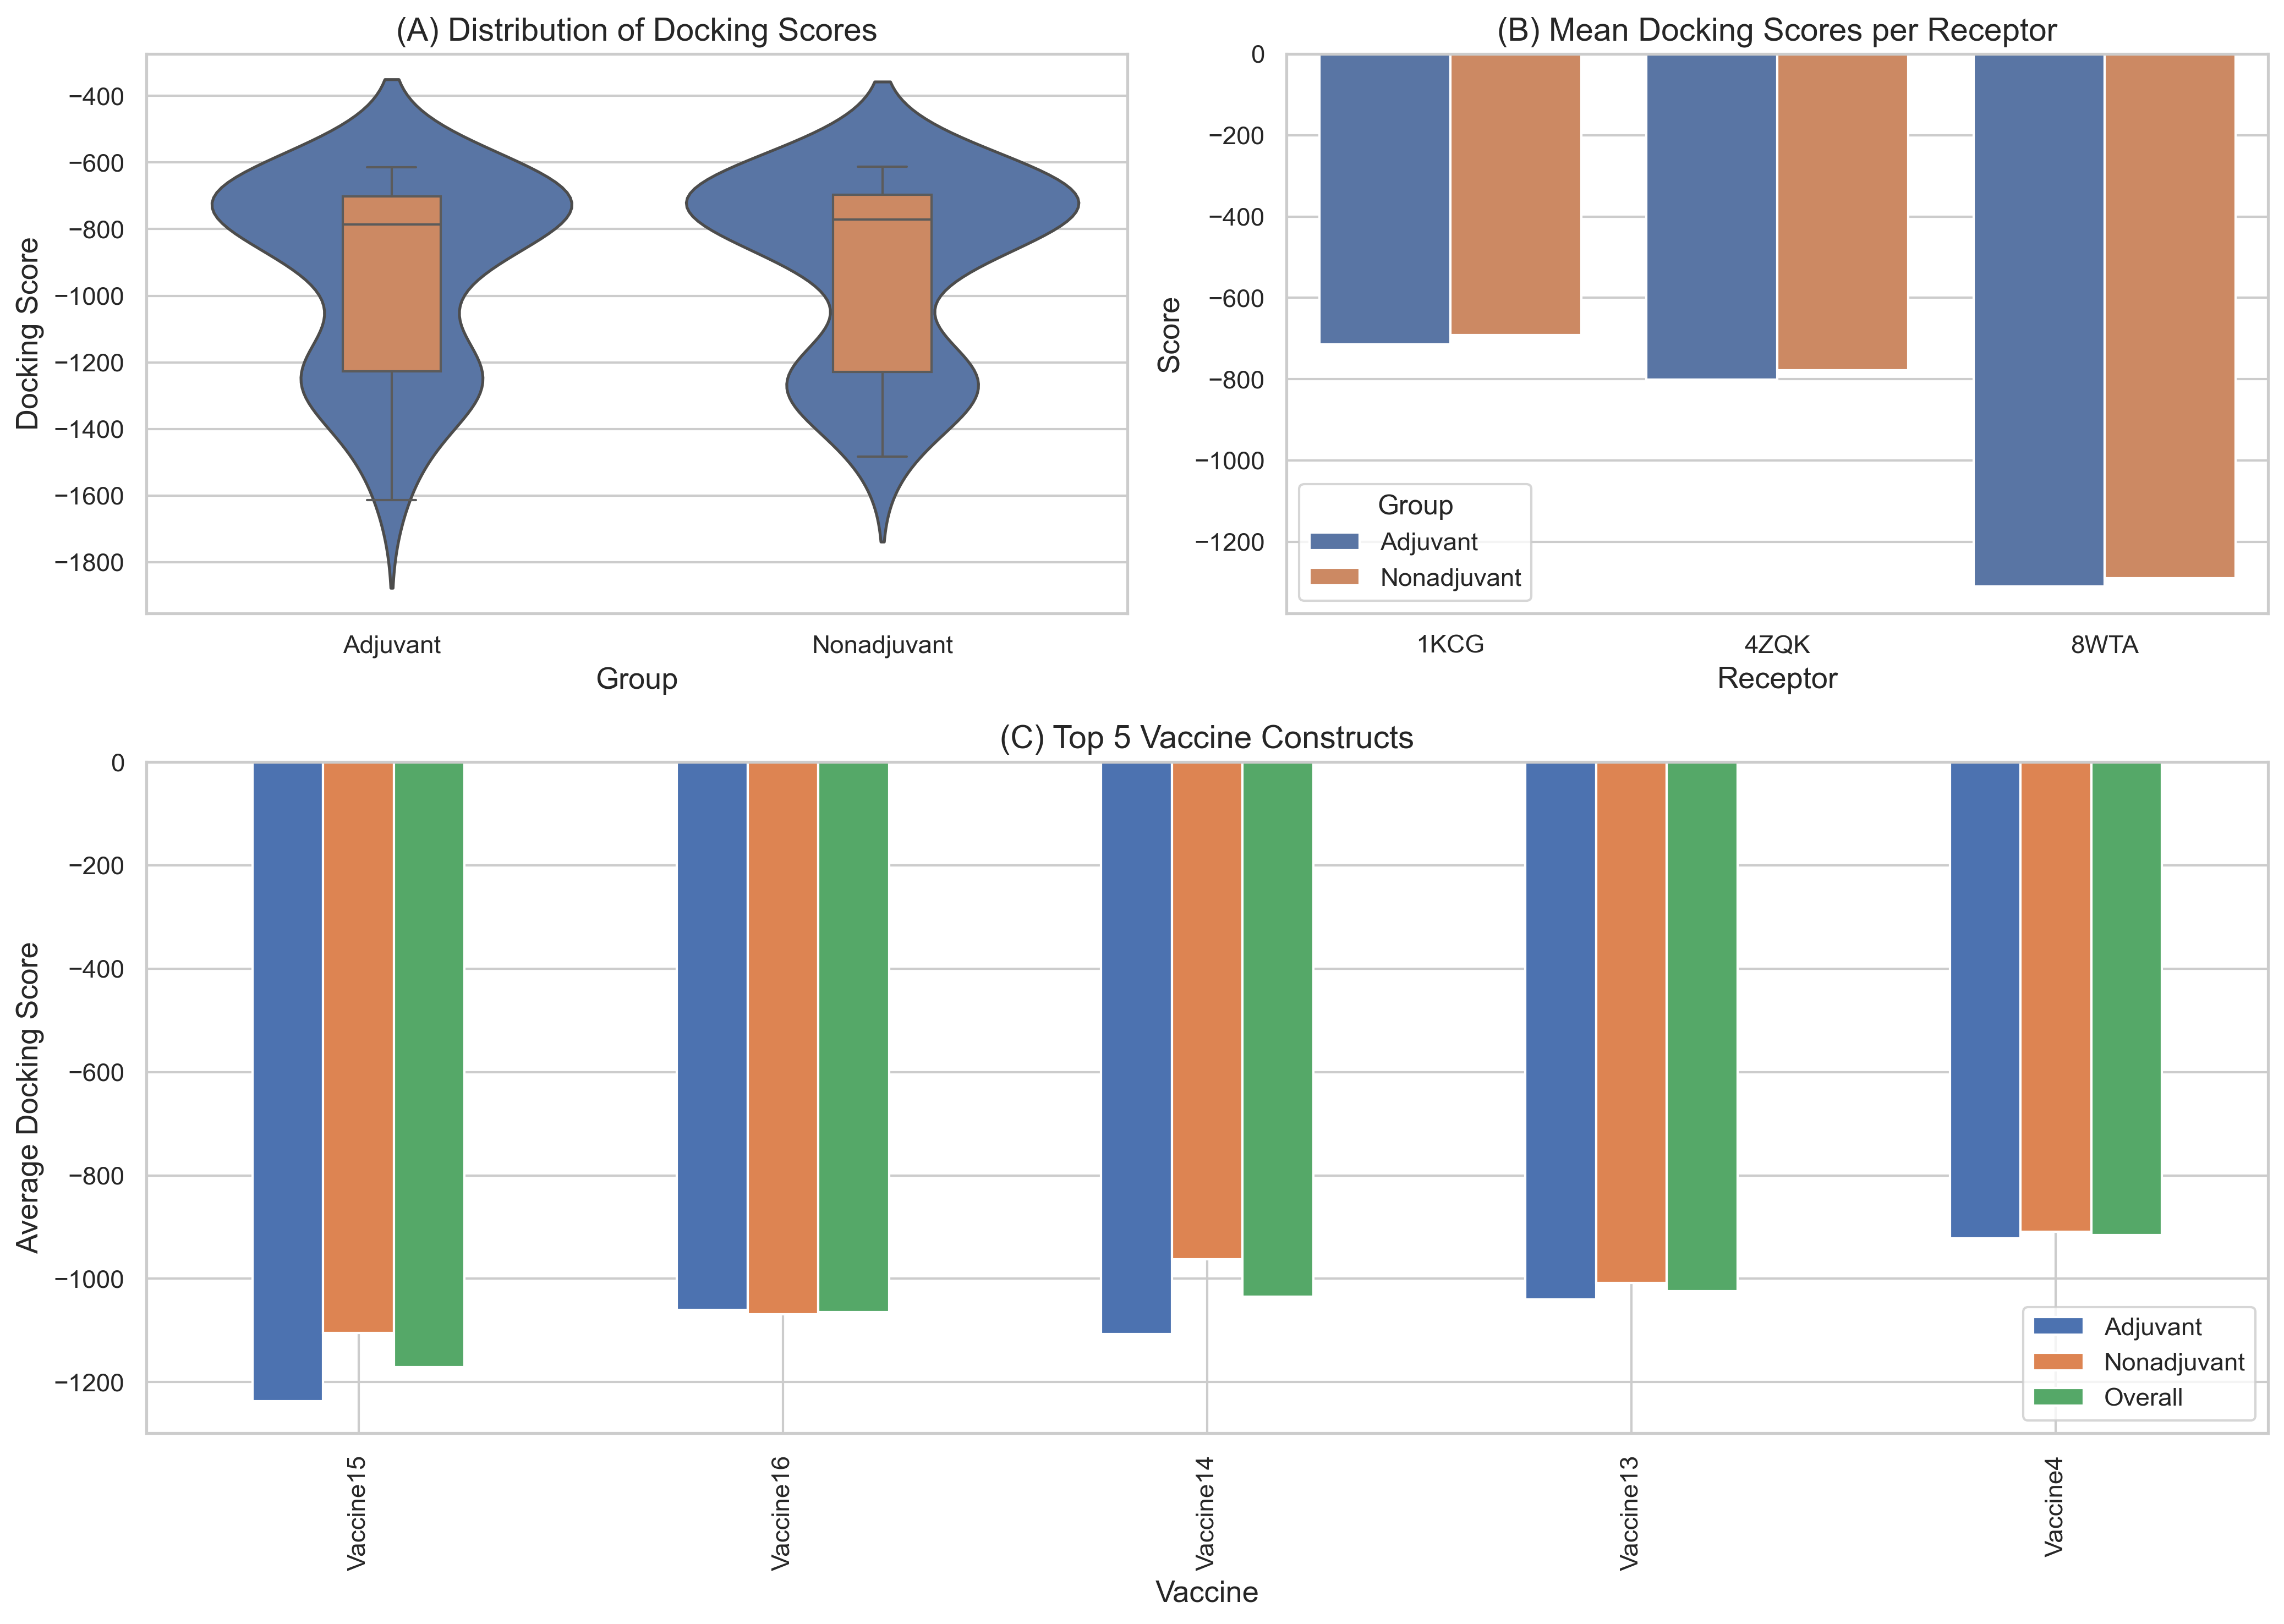

In [5]:
fig = plt.figure(figsize=(14,10))

gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[1,1.2]
)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,:])

# ------------------------------------------------
# Panel A
# ------------------------------------------------

plot_df = pd.melt(
    df,
    value_vars=["Adjuvant","Nonadjuvant"],
    var_name="Group",
    value_name="Docking Score"
)

sns.violinplot(
    data=plot_df,
    x="Group",
    y="Docking Score",
    inner=None,
    ax=ax1
)

sns.boxplot(
    data=plot_df,
    x="Group",
    y="Docking Score",
    width=0.2,
    ax=ax1
)

ax1.set_title("(A) Distribution of Docking Scores")

# ------------------------------------------------
# Panel B
# ------------------------------------------------

mean_scores = (
    df.groupby("Receptor")
      [["Adjuvant","Nonadjuvant"]]
      .mean()
      .reset_index()
)

mean_scores = mean_scores.melt(
    id_vars="Receptor",
    var_name="Group",
    value_name="Score"
)

sns.barplot(
    data=mean_scores,
    x="Receptor",
    y="Score",
    hue="Group",
    ax=ax2
)

ax2.set_title("(B) Mean Docking Scores per Receptor")

# ------------------------------------------------
# Panel C
# ------------------------------------------------

top5 = (
    df.groupby("Vaccine")
      [["Adjuvant","Nonadjuvant"]]
      .mean()
)

top5["Overall"] = (
    top5["Adjuvant"] +
    top5["Nonadjuvant"]
)/2

top5 = top5.sort_values(
    "Overall"
).head(5)

top5.plot(
    kind="bar",
    ax=ax3
)

ax3.set_title("(C) Top 5 Vaccine Constructs")
ax3.set_ylabel("Average Docking Score")

plt.tight_layout()

plt.savefig(
    "Figure7_Combined.png",
    bbox_inches="tight"
)

plt.savefig(
    "Figure7_Combined.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Figure7_Combined.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

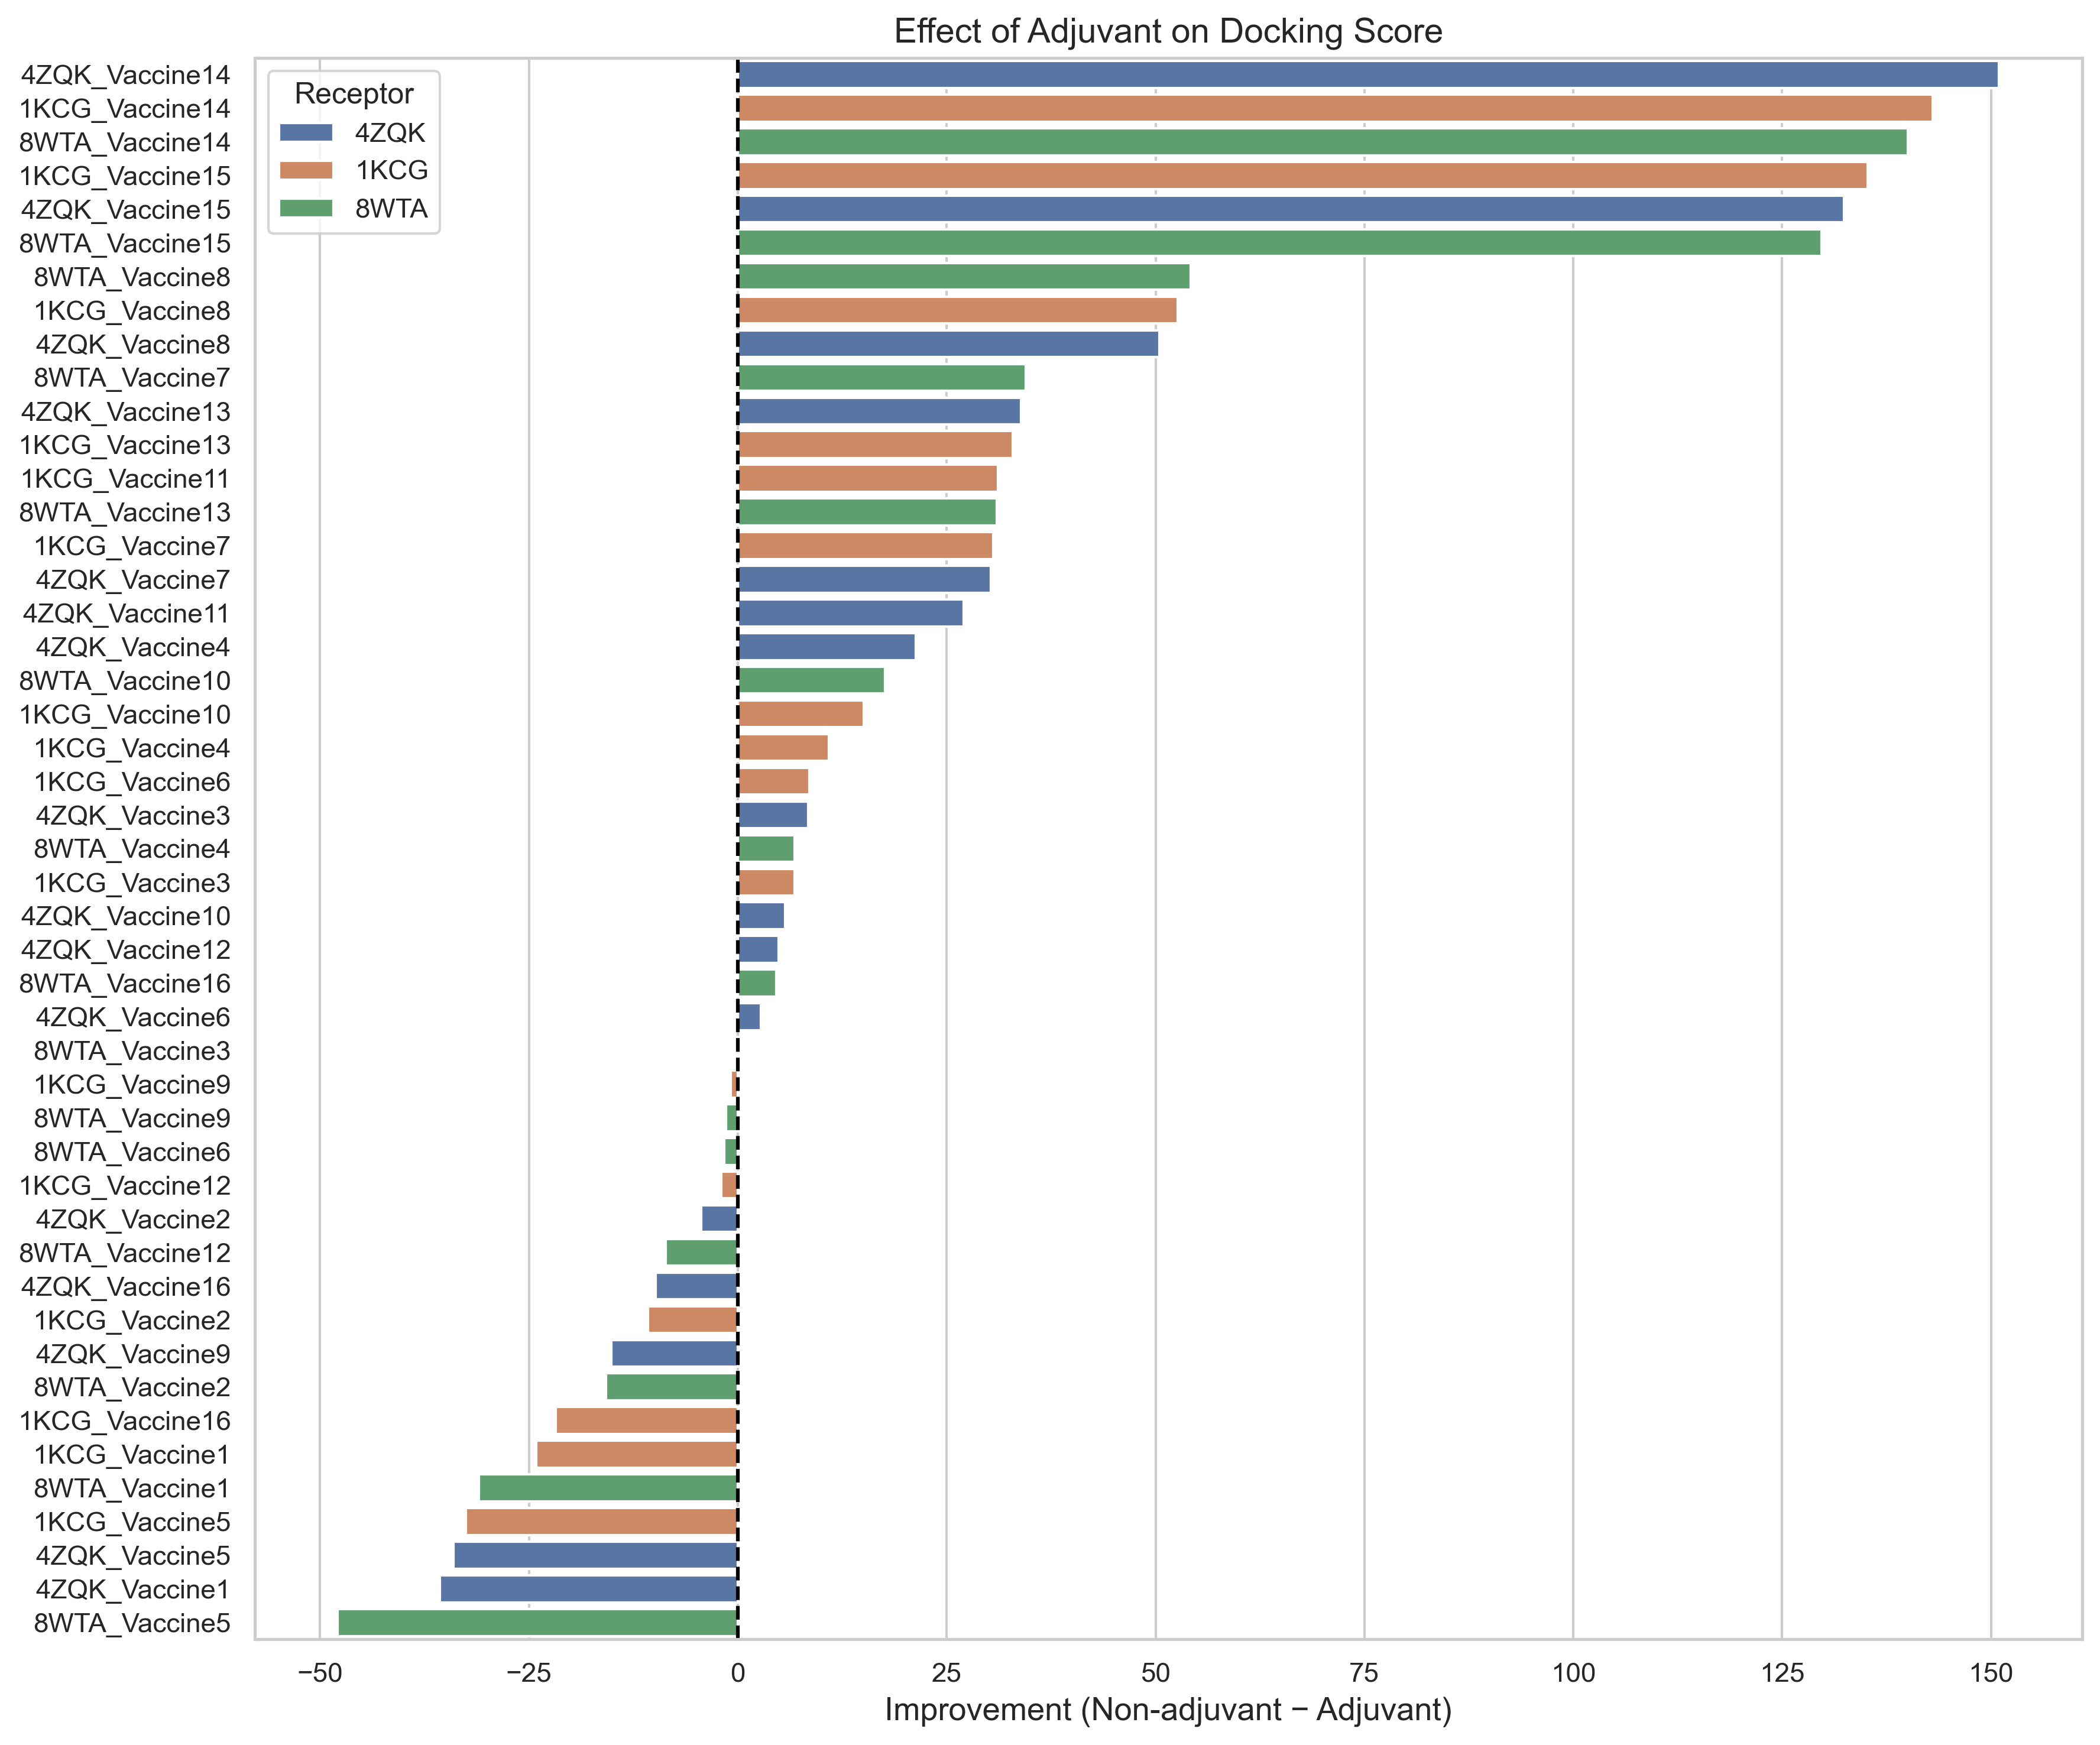

In [6]:
effect_df = df.copy()

effect_df["Pair"] = (
    effect_df["Receptor"]
    + "_"
    + effect_df["Vaccine"]
)

effect_df = effect_df.sort_values(
    "Improvement",
    ascending=False
)

plt.figure(figsize=(12,10))

sns.barplot(
    data=effect_df,
    y="Pair",
    x="Improvement",
    hue="Receptor",
    dodge=False
)

plt.axvline(
    0,
    linestyle="--",
    color="black"
)

plt.title(
    "Effect of Adjuvant on Docking Score"
)

plt.xlabel(
    "Improvement (Non-adjuvant − Adjuvant)"
)

plt.ylabel("")

plt.tight_layout()

plt.savefig(
    "Figure8_Improvement.png",
    bbox_inches="tight"
)

plt.savefig(
    "Figure8_Improvement.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Figure8_Improvement.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

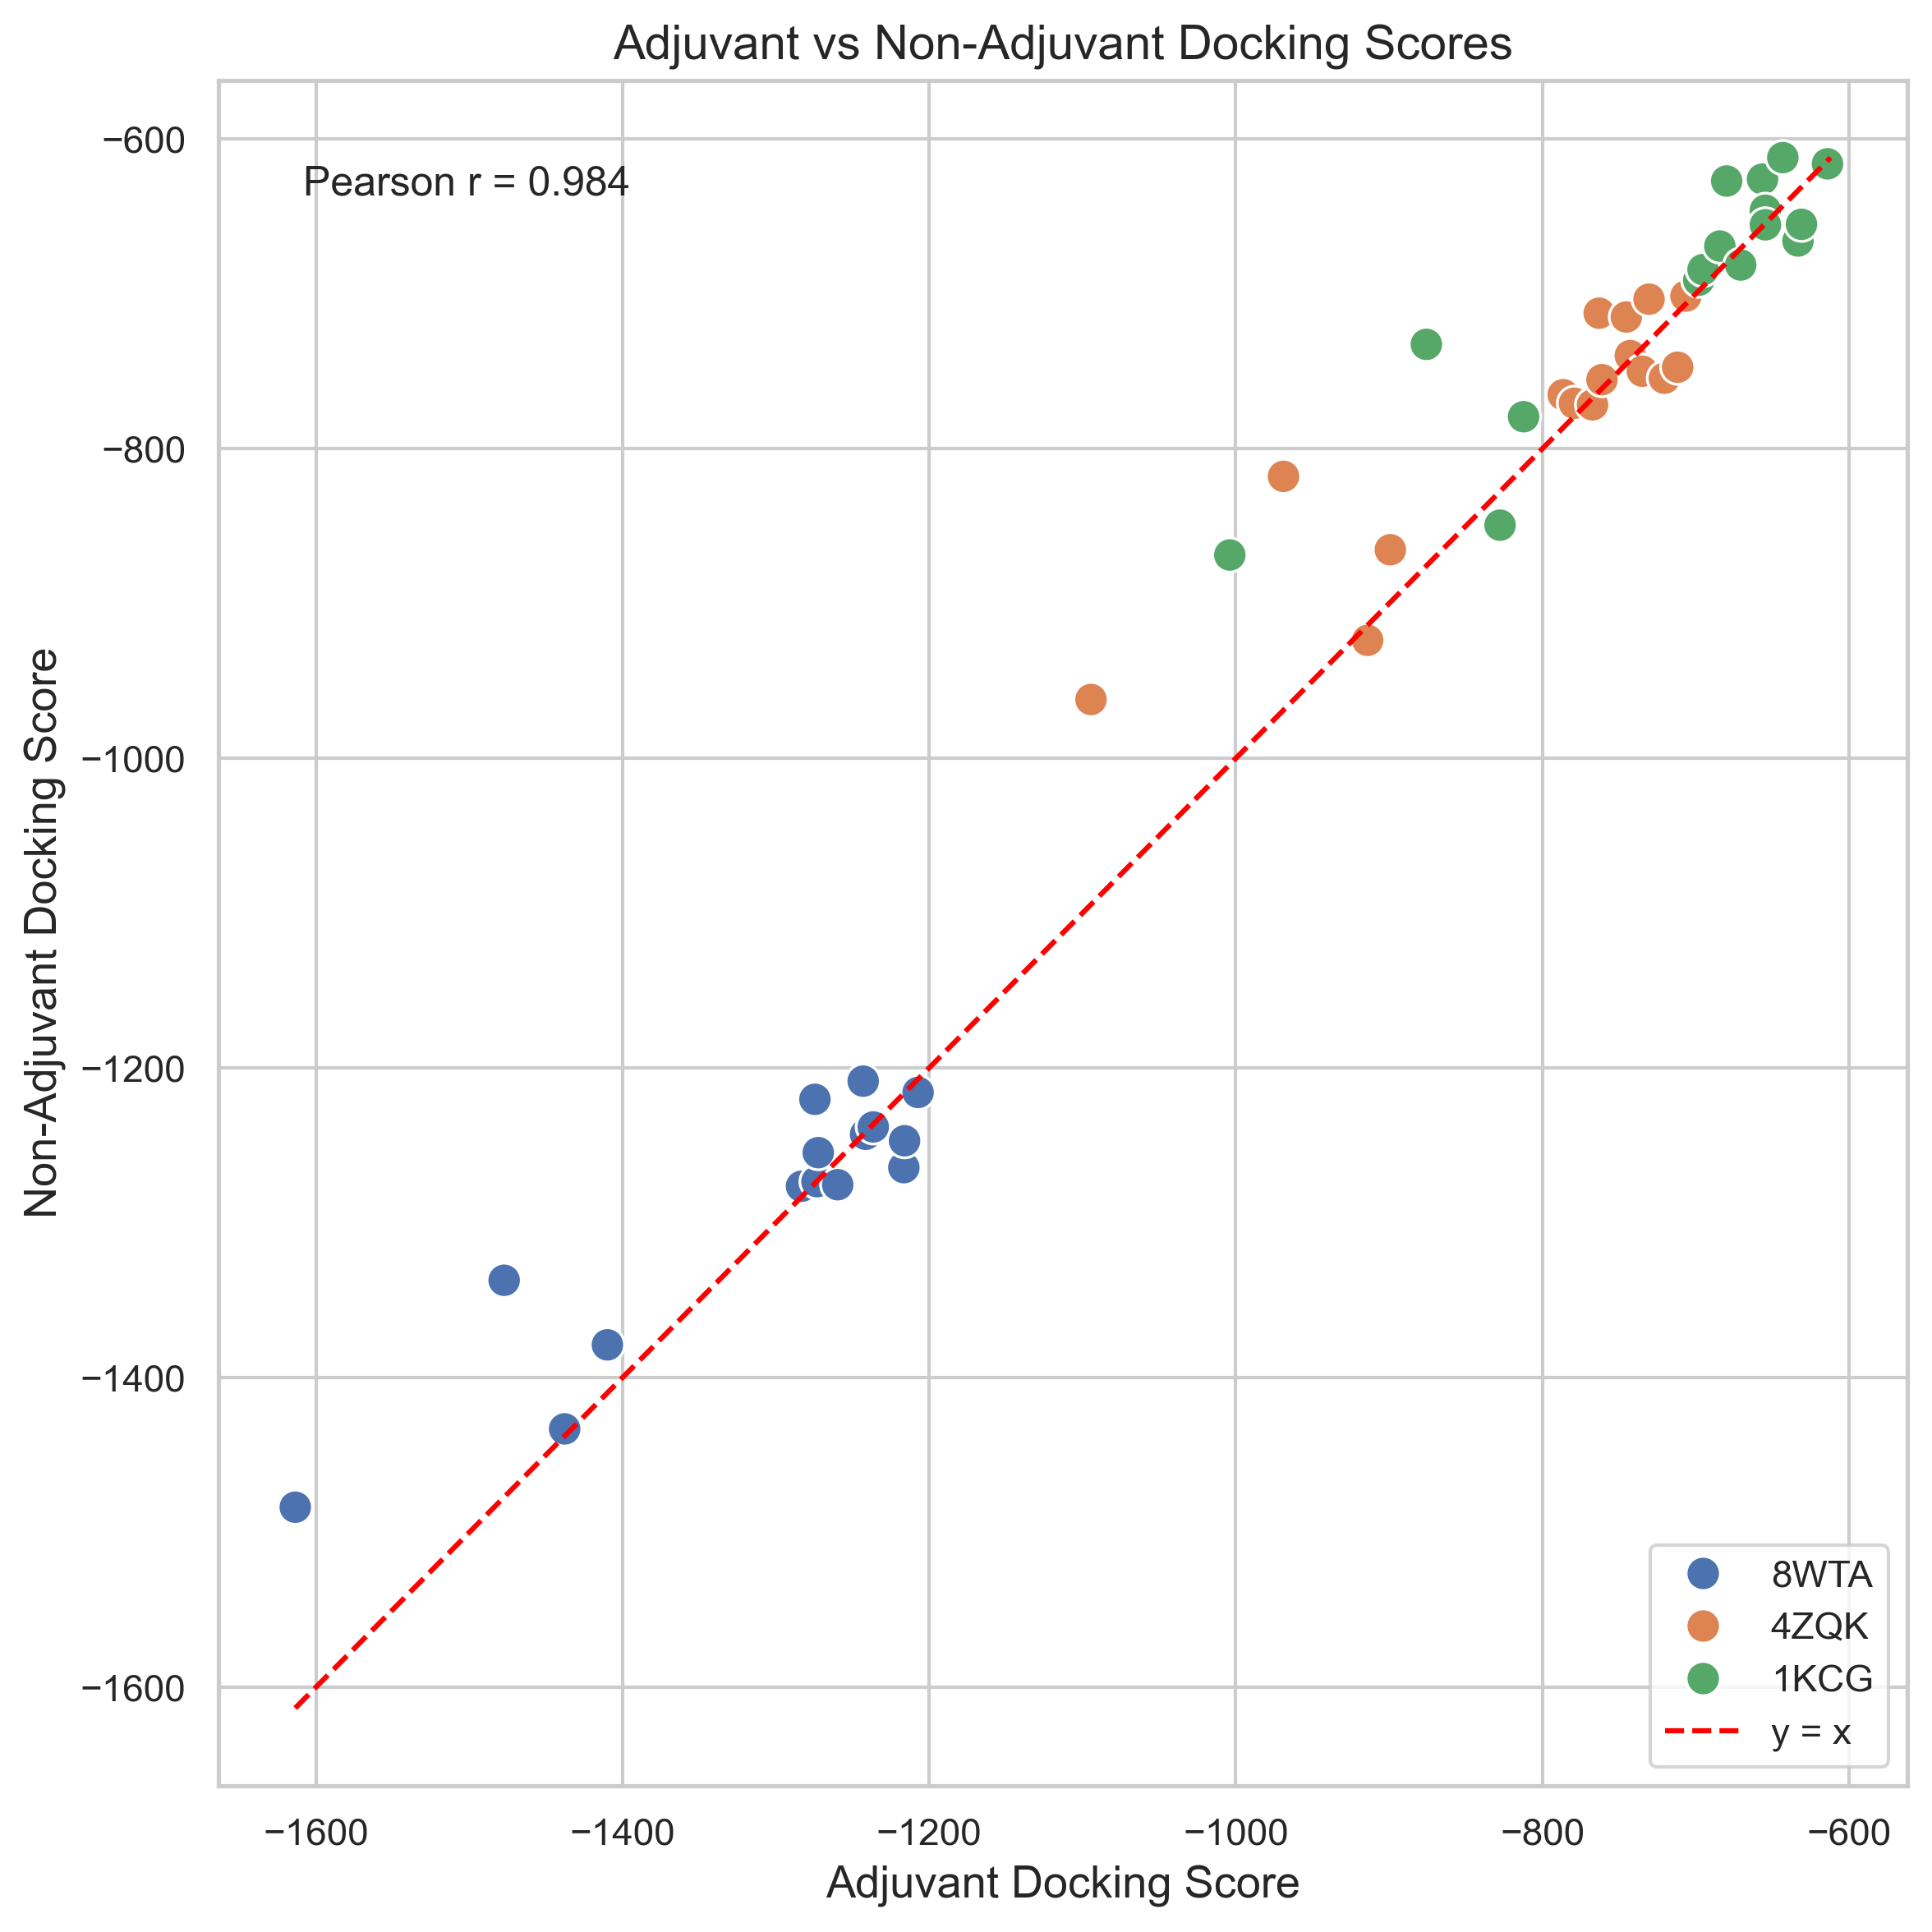

In [7]:
plt.figure(figsize=(8,8))

sns.scatterplot(
    data=df,
    x="Adjuvant",
    y="Nonadjuvant",
    hue="Receptor",
    s=100
)

xmin = min(
    df["Adjuvant"].min(),
    df["Nonadjuvant"].min()
)

xmax = max(
    df["Adjuvant"].max(),
    df["Nonadjuvant"].max()
)

plt.plot(
    [xmin,xmax],
    [xmin,xmax],
    '--',
    color='red',
    label='y = x'
)

r,p = pearsonr(
    df["Adjuvant"],
    df["Nonadjuvant"]
)

plt.text(
    0.05,
    0.95,
    f"Pearson r = {r:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.title(
    "Adjuvant vs Non-Adjuvant Docking Scores"
)

plt.xlabel(
    "Adjuvant Docking Score"
)

plt.ylabel(
    "Non-Adjuvant Docking Score"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "Figure9_Scatter.png",
    bbox_inches="tight"
)

plt.savefig(
    "Figure9_Scatter.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Figure9_Scatter.tiff",
    dpi=600,
    bbox_inches="tight"
)

plt.show()